**Step 1 : Data Extraction**

Load Package

In [ ]:
# Install packages
!pip install datasets bertopic sentence-transformers transformers torch seaborn matplotlib networkx

# Imports
from datasets import load_dataset, concatenate_datasets
import pandas as pd


Load Dataset & Combine All Events

In [ ]:
event_list = [
    "california_wildfires_2018","canada_wildfires_2016","cyclone_idai_2019",
    "ecuador_earthquake_2016","greece_wildfires_2018","hurricane_florence_2018",
    "hurricane_dorian_2019","hurricane_harvey_2017","hurricane_irma_2017",
    "hurricane_maria_2017","hurricane_matthew_2016","italy_earthquake_aug_2016",
    "kaikoura_earthquake_2016","kerala_floods_2018","maryland_floods_2018",
    "midwestern_us_floods_2019","pakistan_earthquake_2019",
    "puebla_mexico_earthquake_2017","srilanka_floods_2017"
]

all_datasets = []

for event in event_list:
    ds = load_dataset("QCRI/HumAID-events", event, split="train")
    ds = ds.add_column("event", [event]*len(ds))
    all_datasets.append(ds)

combined_dataset = concatenate_datasets(all_datasets)
df = combined_dataset.to_pandas()

Checks

In [ ]:
import pandas as pd

# Event-wise Tweet Count (19 events)
total_tweets = len(df)
print("Total number of tweets:", total_tweets)
event_summary = df['event'].value_counts().reset_index()
event_summary.columns = ['Event Name', 'Tweet Count']
display(event_summary)

Total number of tweets: 53531


,Event Name,Tweet Count
0,hurricane_irma_2017,6579
1,hurricane_harvey_2017,6378
2,kerala_floods_2018,5588
3,hurricane_dorian_2019,5329
4,california_wildfires_2018,5163
5,hurricane_maria_2017,5094
6,hurricane_florence_2018,4384
7,cyclone_idai_2019,2753
8,canada_wildfires_2016,1569
9,kaikoura_earthquake_2016,1536


Load Concatanated Data

In [ ]:
import pandas as pd

# 'combined_dataset' holds all your loaded and concatenated data
df_features = combined_dataset.to_pandas()
df_features.head()

,tweet_id,tweet_text,class_label,event
0,1061651759158853632,Smoking ruins and a mobile DNA lab: California...,injured_or_dead_people,california_wildfires_2018
1,1064599072151990273,"California’s utility, PG&amp;E was responsible...",other_relevant_information,california_wildfires_2018
2,1061239977282072577,At least 9 dead in California wildfires as ten...,injured_or_dead_people,california_wildfires_2018
3,1063608886995898368,RT @WGNNews: At least 66 dead in California wi...,injured_or_dead_people,california_wildfires_2018
4,1064157198350086145,25K - + homeless &amp; from the #DeranfgedOran...,injured_or_dead_people,california_wildfires_2018


**Step 2 : Data Preprocessing**

Clean Text

In [ ]:
import re
import pandas as pd

# Use the existing DataFrame 'df_features' which contains the combined data
train_df = df_features.copy() # Create a copy to avoid modifying df_features directly if not desired

# Simple preprocessing function
def preprocess_tweet(text):
    text = text.lower()                                  # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r"@\w+", '', text)                     # Remove mentions
    text = re.sub(r"#", '', text)                        # Remove hashtags
    text = re.sub(r"[^A-Za-z0-9\s]", '', text)           # Remove special chars
    text = re.sub(r"\s+", ' ', text).strip()             # Remove extra spaces
    return text

train_df['clean_text'] = train_df['tweet_text'].apply(preprocess_tweet)
train_df.head()

,tweet_id,tweet_text,class_label,event,clean_text
0,1061651759158853632,Smoking ruins and a mobile DNA lab: California...,injured_or_dead_people,california_wildfires_2018,smoking ruins and a mobile dna lab california ...
1,1064599072151990273,"California’s utility, PG&amp;E was responsible...",other_relevant_information,california_wildfires_2018,californias utility pgampe was responsible for...
2,1061239977282072577,At least 9 dead in California wildfires as ten...,injured_or_dead_people,california_wildfires_2018,at least 9 dead in california wildfires as ten...
3,1063608886995898368,RT @WGNNews: At least 66 dead in California wi...,injured_or_dead_people,california_wildfires_2018,rt at least 66 dead in california wildfires mo...
4,1064157198350086145,25K - + homeless &amp; from the #DeranfgedOran...,injured_or_dead_people,california_wildfires_2018,25k homeless amp from the deranfgedorangeman i...


BERT Classification**

DistilBERT

In [ ]:
# Install (run once)
!pip install transformers scikit-learn

# IMPORTS
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 1. USE SMALL SAMPLE (FAST!)
df_fast = train_df[['clean_text', 'class_label']].dropna().copy()

# Take only 5000 samples (FAST)
df_fast = df_fast.sample(5000, random_state=42)

# Encode labels
df_fast['label'] = df_fast['class_label'].astype('category').cat.codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_fast['clean_text'].tolist(),
    df_fast['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_fast['label']
)

# 2. TOKENIZER (FAST MODEL)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=64)

train_labels = torch.tensor(y_train)
test_labels = torch.tensor(y_test)


# 3. DATASET CLASS
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TweetDataset(train_encodings, train_labels)
test_dataset = TweetDataset(test_encodings, test_labels)

# 4. FAST MODEL
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(df_fast['label'].unique())
)

# 5. METRICS
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# 6. TRAINING ARGUMENTS (FAST)
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=1,   # only 1 epoch = FAST
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",
    save_strategy="no",

    logging_steps=100,
    report_to="none",

    fp16=torch.cuda.is_available()
)


# 7. TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# 8. TRAIN
trainer.train()

# 9. EVALUATE
results = trainer.evaluate()

print("===== FAST MODEL RESULTS =====")
print(results)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.917429,0.904221,0.698000,0.672396


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


===== FAST MODEL RESULTS =====
{'eval_loss': 0.9042214751243591, 'eval_accuracy': 0.698, 'eval_f1': 0.6723957695731719, 'eval_runtime': 104.8725, 'eval_samples_per_second': 9.535, 'eval_steps_per_second': 1.192, 'epoch': 1.0}


**Step 3 : Time Slicing**

Chronological Slice

In [ ]:
df = df.reset_index(drop=True)

df['time_slice'] = pd.qcut(
    df.index,
    q=3,
    labels=[1,2,3]
)

Time Slice Table

In [ ]:
time_table = df['time_slice'].value_counts().sort_index()
print(time_table)

time_slice
1    17844
2    17843
3    17844
Name: count, dtype: int64


Define Phases

In [ ]:
mapping = {1:'Early', 2:'Peak', 3:'Recovery'}
df['phase'] = df['time_slice'].map(mapping)

**Step 4 : Topic Modeling (BERTopic + LDA)**

BERTopic per Time Slice

In [ ]:
from bertopic import BERTopic

# Add the 'clean_text' column from 'train_df' to 'df'
# Assuming 'df' and 'train_df' have the same row order and index alignment
df['clean_text'] = train_df['clean_text']

topic_results = []

for slice_id in [1,2,3]:
    subset = df[df['time_slice'] == slice_id]

    docs = subset['clean_text'].tolist()

    model = BERTopic(verbose=False)
    topics, _ = model.fit_transform(docs)

    subset = subset.copy()
    subset['topic'] = topics

    topic_results.append(subset)

df_topics = pd.concat(topic_results)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cluster Count

In [ ]:
topic_counts = df_topics['topic'].value_counts()
print(topic_counts.head())

topic
-1    19484
 0     4205
 1     2405
 2     1892
 3     1155
Name: count, dtype: int64


LDA

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

LatentDirichletAllocation(random_state=42)

Keyword and Topic

In [ ]:
import pandas as pd

# ================================
# 1. Get Topic Info from BERTopic
# ================================
topic_info = model.get_topic_info()

# Remove noise topic (-1)
topic_info = topic_info[topic_info['Topic'] != -1].copy()

# ================================
# 2. Extract Keywords Function
# ================================
def get_keywords(topic_id):
    words = model.get_topic(topic_id)
    if words:
        return ", ".join([w[0] for w in words])
    return ""

topic_info['Keywords'] = topic_info['Topic'].apply(get_keywords)

# ================================
# 3. Add Sample Tweets per Topic
# ================================
sample_tweets_list = []

for topic_id in topic_info['Topic']:
    tweets = df_topics[df_topics['topic'] == topic_id]['clean_text'].head(5).tolist()

    sample_tweets_list.append(" | ".join(tweets))

topic_info['Sample Tweets'] = sample_tweets_list

# ================================
# 4. Final Clean Table
# ================================
topic_summary_table = topic_info[['Topic', 'Count', 'Keywords', 'Sample Tweets']]

# Sort by most important topics
topic_summary_table = topic_summary_table.sort_values(by='Count', ascending=False)

# ================================
# 5. Show Output
# ================================
print("\n===== TOPIC SUMMARY TABLE =====\n")
display(topic_summary_table)


===== TOPIC SUMMARY TABLE =====



,Topic,Count,Keywords,Sample Tweets
1,0,956,"nebraska, flooding, iowa, farmers, nebraskastr...",your efforts are noticed and appreciated | ver...
2,1,653,"italyearthquake, italy, prayforitaly, terremot...",sumpri camping survival gear 36 inch pocket ch...
3,2,617,"maria, puerto, rico, hurricane, power, destroy...",our greek life interest group at sou is partic...
4,3,341,"haiti, matthew, hurricanematthew, hurricane, h...",don milburn and nick ostrosky will make the lo...
5,4,334,"srilanka, floodsl, lka, sri, lanka, landslides...",florence is now a strong tropical storm with w...
...,...,...,...,...
168,167,10,"water, clean, flight, drinking, food, distribu...",st martins famous airport badly damaged by hur...
169,168,10,"hoax, climate, change, cpm, chinese, become, c...",fema says dorian could bring storm surge dange...
170,169,10,"armed, forces, opmadad, regiment, rescued, ind...",harvey upped to category 2 hurricane with 110 ...
171,170,10,"gst, tax, gstcouncil, plazas, date, audit, ji,...",the nations largest oil refinery shuts down as...


Cross - Crisis Comparison

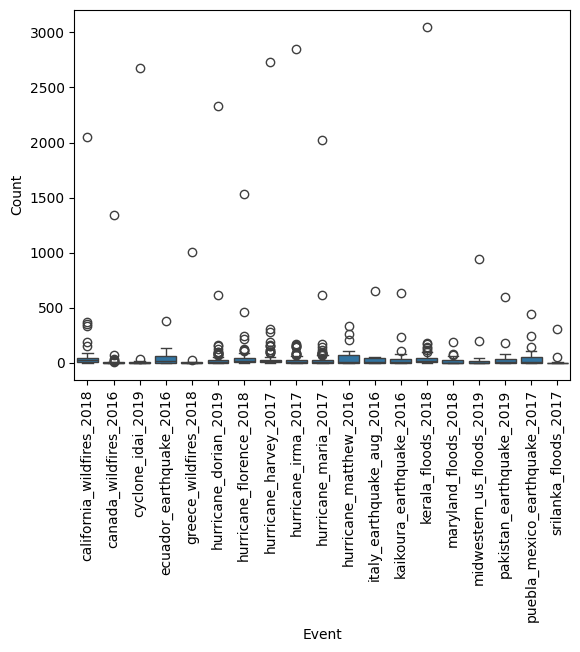

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

event_topic = df_topics.groupby(['event','topic']).size().reset_index(name='Count')
event_topic = event_topic.rename(columns={'event': 'Event'})

sns.boxplot(data=event_topic, x='Event', y='Count')
plt.xticks(rotation=90)
plt.show()

**Step 5 : Temporal Topic Analysis**

Frequency Tracking

In [ ]:
topic_time = df_topics.groupby(['time_slice','topic']).size().reset_index(name='Count')
topic_time = topic_time.rename(columns={'time_slice': 'Time_slice'})

Compute Metrics

In [ ]:
metrics = []

for topic in df_topics['topic'].unique():
    counts = topic_time[topic_time['topic']==topic].sort_values('time_slice')['count'].values

    if len(counts) == 3:
        emergence = next((i+1 for i,x in enumerate(counts) if x>0), None)
        peak = max(counts)
        persistence = sum(counts>0)

        metrics.append({
            'topic': topic,
            'emergence': emergence,
            'peak': peak,
            'persistence': persistence
        })

metrics_df = pd.DataFrame(metrics)

Heatmap

Shape before pivot: (645, 3)
Pivot shape: (10, 3)
time_slice     1    2    3
topic                     
0           2717  532  956
1           1434  318  653
2           1009  266  617
3            623  191  341
4            465  178  334


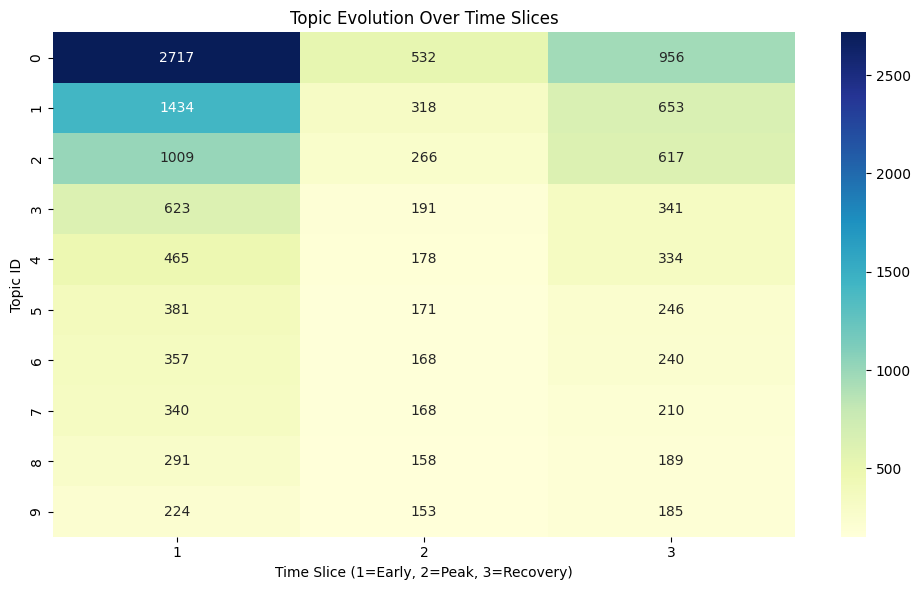

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Remove noise topic (-1)
heatmap_df = topic_time[topic_time['topic'] != -1].copy()

# 2. Check if data exists
print("Shape before pivot:", heatmap_df.shape)


# 3. Keep only TOP 10 topics
top_topics = (
    heatmap_df.groupby('topic')['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_df = heatmap_df[heatmap_df['topic'].isin(top_topics)]

# 4. Create pivot table
pivot = heatmap_df.pivot_table(
    index='topic',
    columns='time_slice',
    values='count',
    aggfunc='sum',
    fill_value=0
)

print("Pivot shape:", pivot.shape)
print(pivot.head())  # Debug


# 5. Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap='YlGnBu'
)

plt.title("Topic Evolution Over Time Slices")
plt.xlabel("Time Slice (1=Early, 2=Peak, 3=Recovery)")
plt.ylabel("Topic ID")
plt.tight_layout()
plt.show()

Scatter Plot

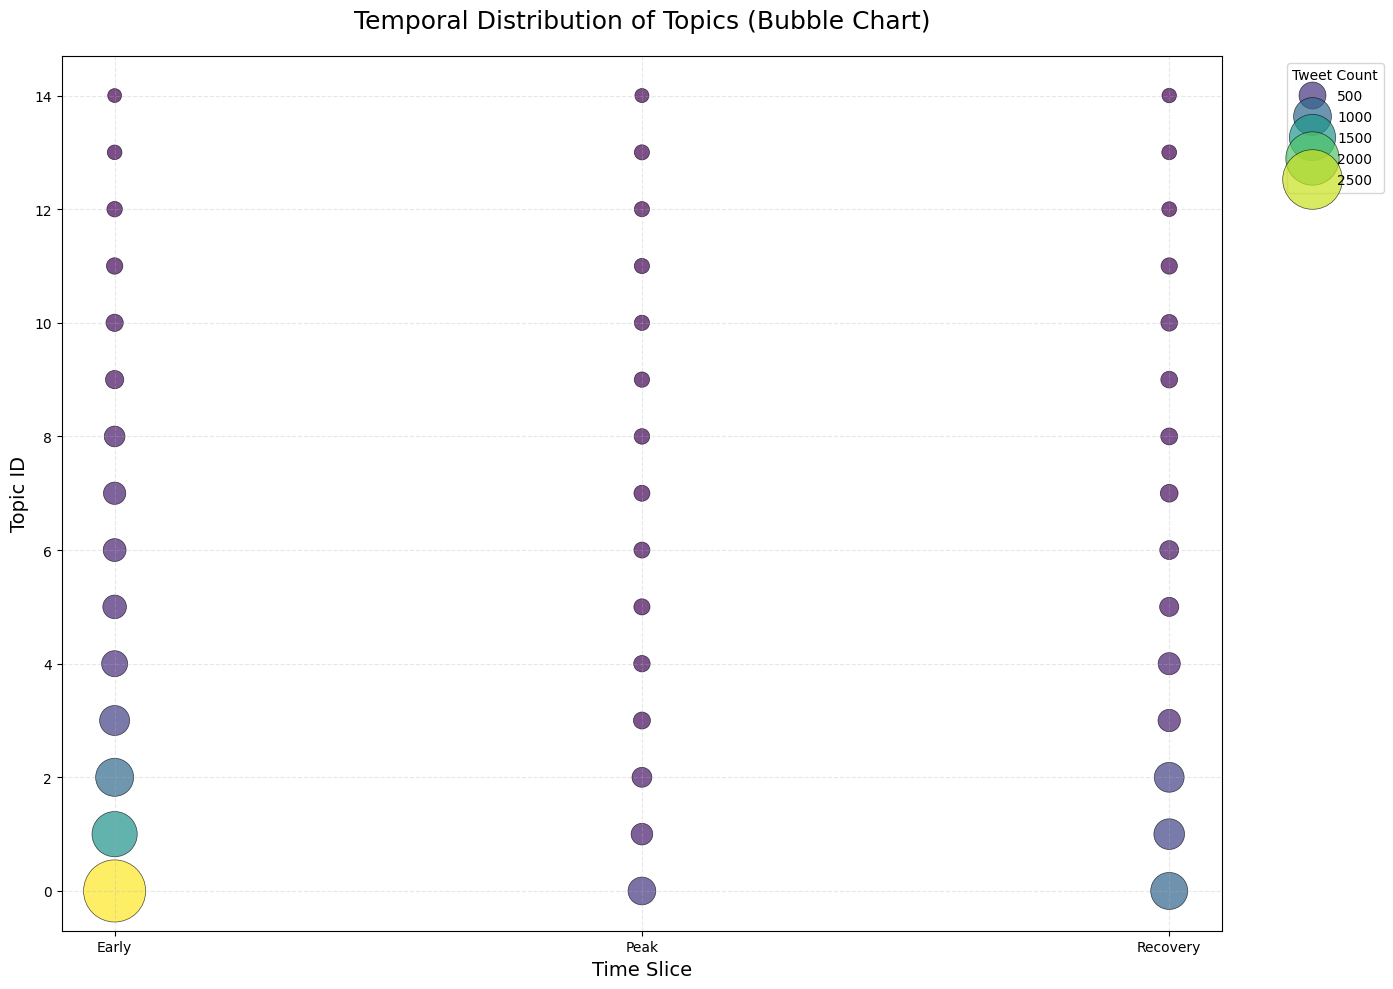

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Remove noise topic (-1)
plot_df = topic_time[topic_time['topic'] != -1].copy()

# 2. Keep only TOP 15 topics (IMPORTANT)
top_topics = (
    plot_df.groupby('topic')['count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plot_df = plot_df[plot_df['topic'].isin(top_topics)]

# 3. Create detailed scatter plot
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x='time_slice',
    y='topic',
    size='count',
    hue='count',
    sizes=(100, 2000),     # Bigger bubbles
    palette='viridis',     # Better color gradient
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# 4. Improve labels and layout
plt.title("Temporal Distribution of Topics (Bubble Chart)", fontsize=18, pad=20)

plt.xlabel("Time Slice", fontsize=14)
plt.ylabel("Topic ID", fontsize=14)

# Replace numeric slices with labels
plt.xticks([1, 2, 3], ['Early', 'Peak', 'Recovery'])

# Grid for clarity
plt.grid(True, linestyle='--', alpha=0.3)

# Move legend outside
plt.legend(title="Tweet Count", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Visualization

Scatter Plot

<Axes: xlabel='Time_slice', ylabel='Count'>

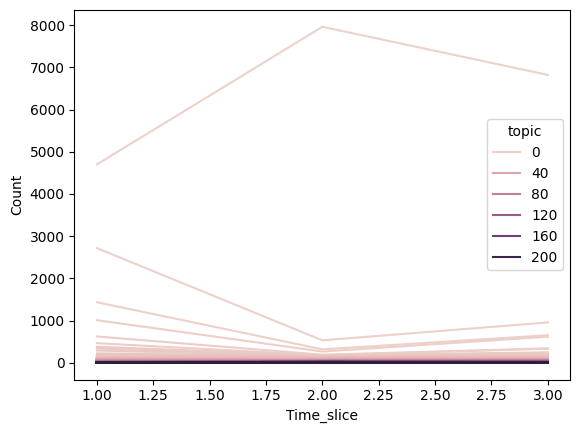

In [ ]:
# Plotting topic count over time with corrected column names
sns.lineplot(data=topic_time, x='Time_slice', y='Count', hue='topic')

**Step 6 : Topic Diffusion Metrics**

Growth + Peak + Persistence

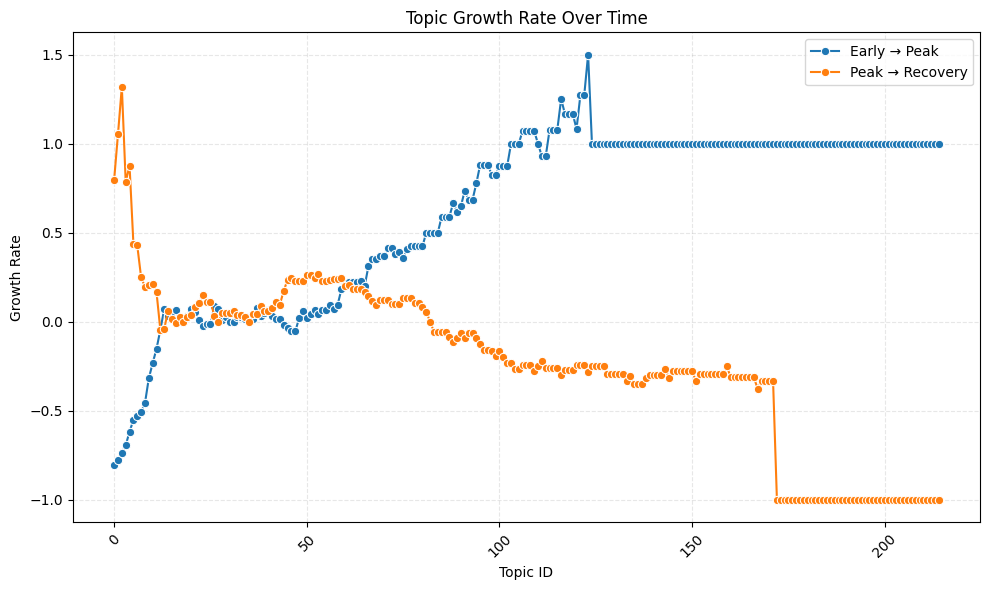

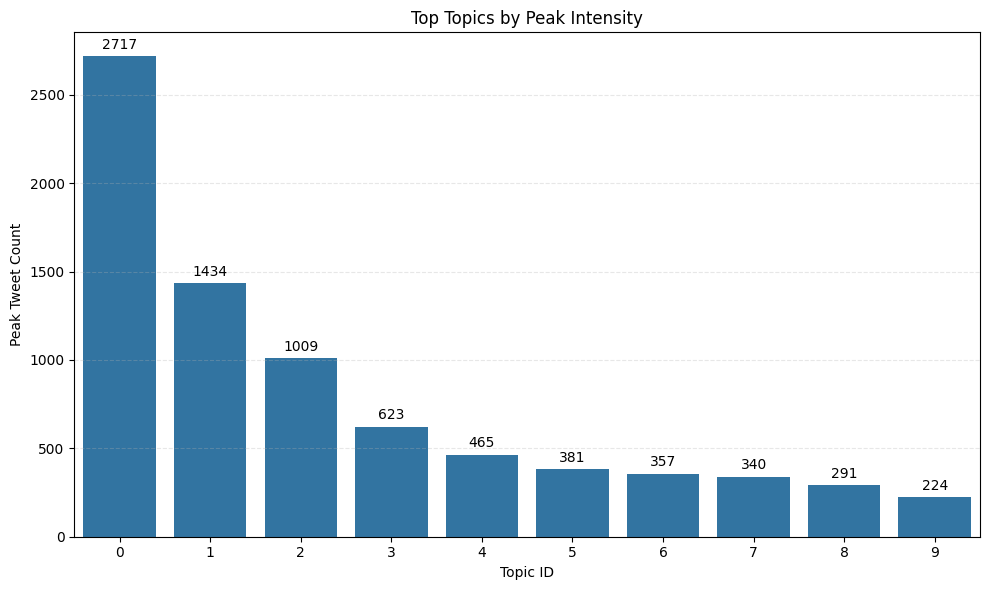

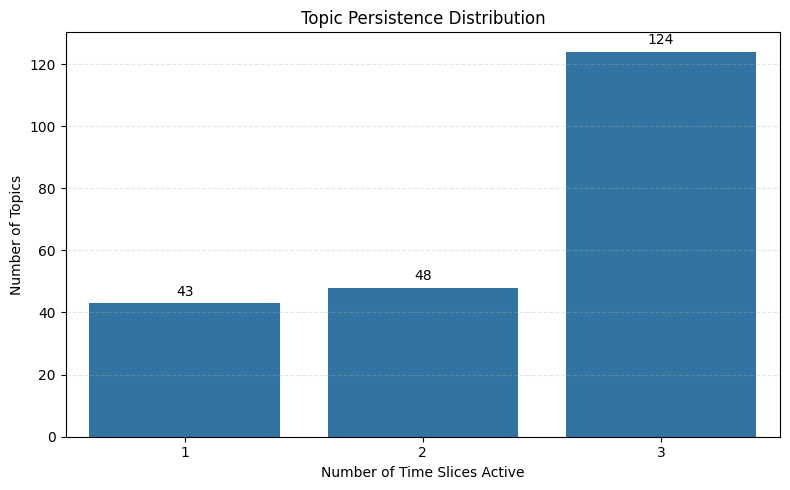

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported

# 0. Define diff_df (This was the missing part causing the NameError)
# Start with metrics_df as it contains 'peak' and 'persistence'
diff_df = metrics_df.copy()

# Ensure 'topic' column is consistent type for merging/indexing
diff_df['topic'] = diff_df['topic'].astype(int)
topic_time['topic'] = topic_time['topic'].astype(int)

# Pivot topic_time to easily access counts for each slice per topic
topic_counts_pivot = topic_time.pivot_table(index='topic', columns='Time_slice', values='Count', fill_value=0)

# Calculate growth rates and add them to diff_df
def calculate_growth(row, topic_counts_pivot):
    topic_id = row['topic']
    growth_1_val = 0.0
    growth_2_val = 0.0

    if topic_id in topic_counts_pivot.index:
        count_t1 = topic_counts_pivot.loc[topic_id, 1]
        count_t2 = topic_counts_pivot.loc[topic_id, 2]
        count_t3 = topic_counts_pivot.loc[topic_id, 3]

        # Growth from Early to Peak (t1 to t2)
        if count_t1 > 0:
            growth_1_val = (count_t2 - count_t1) / count_t1
        else:
            # If early count is 0, and peak > 0, consider it positive growth (e.g., 100% growth from zero)
            growth_1_val = 1.0 if count_t2 > 0 else 0.0

        # Growth from Peak to Recovery (t2 to t3)
        if count_t2 > 0:
            growth_2_val = (count_t3 - count_t2) / count_t2
        else:
            # If peak count is 0, and recovery > 0, consider it positive growth
            growth_2_val = 1.0 if count_t3 > 0 else 0.0
    return pd.Series({'growth_1': growth_1_val, 'growth_2': growth_2_val})

growth_metrics = diff_df.apply(lambda row: calculate_growth(row, topic_counts_pivot), axis=1)
diff_df = pd.concat([diff_df, growth_metrics], axis=1)

# The original line `diff_df[['growth_1', 'growth_2']] = pd.DataFrame(diff_df['growth'].tolist(), index=diff_df.index)`
# is now redundant as growth_1 and growth_2 are directly calculated and added.

# Remove topic -1 if exists
diff_df_clean = diff_df[diff_df['topic'] != -1]

# 2. Growth Rate Visualization
plt.figure(figsize=(10,6))

sns.lineplot(
    data=diff_df_clean,
    x='topic',
    y='growth_1',
    marker='o',
    label='Early → Peak'
)

sns.lineplot(
    data=diff_df_clean,
    x='topic',
    y='growth_2',
    marker='o',
    label='Peak → Recovery'
)

plt.title("Topic Growth Rate Over Time")
plt.xlabel("Topic ID")
plt.ylabel("Growth Rate")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Peak Intensity Bar Chart
# Select top 10 topics by peak
top_peak = diff_df_clean.sort_values(by='peak', ascending=False).head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_peak,
    x='topic',
    y='peak'
)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title("Top Topics by Peak Intensity")
plt.xlabel("Topic ID")
plt.ylabel("Peak Tweet Count")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Persistence Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=diff_df_clean,
    x='persistence'
)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title("Topic Persistence Distribution")
plt.xlabel("Number of Time Slices Active")
plt.ylabel("Number of Topics")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Step 6 : Topic Transition Graph**

Network Graph

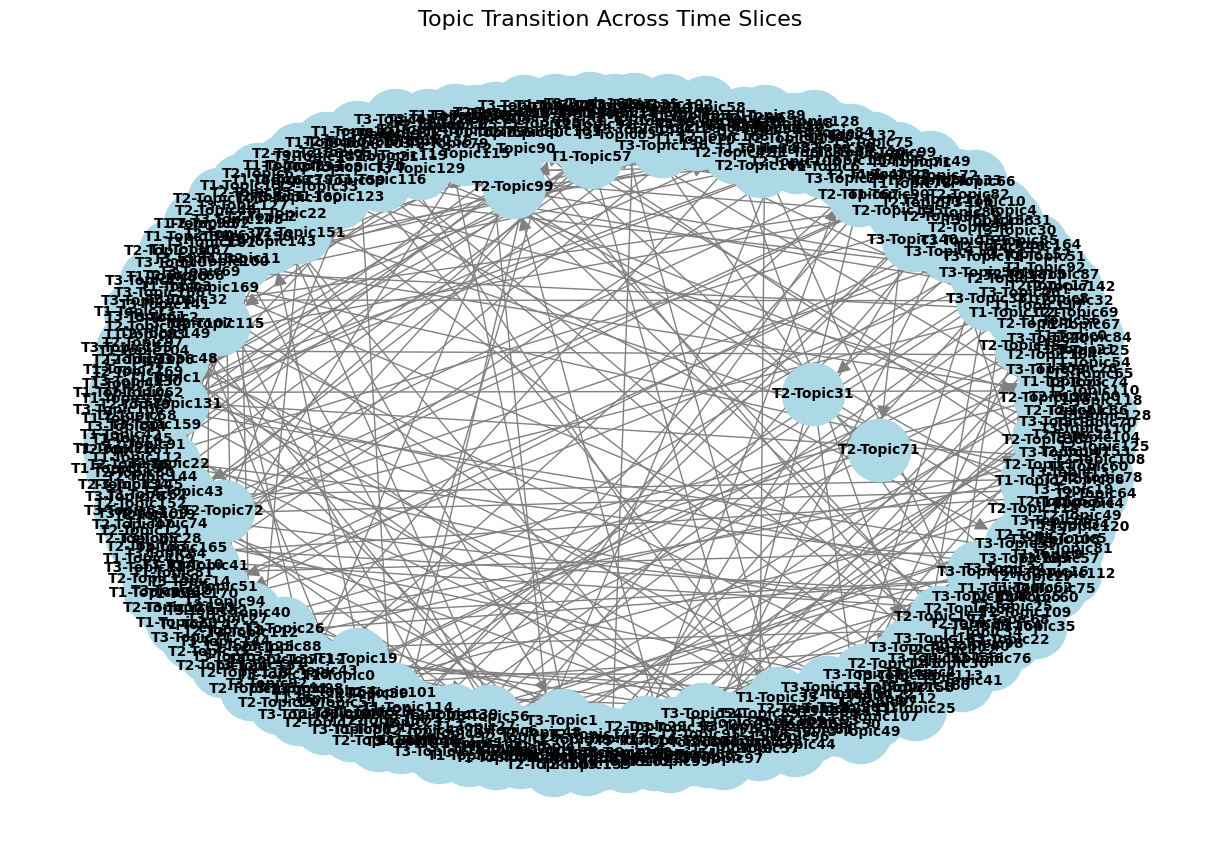

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Build Graph (Clean)
G = nx.DiGraph()

for t in [1, 2]:
    prev_topics = df_topics[df_topics['time_slice']==t]['topic'].unique()
    next_topics = df_topics[df_topics['time_slice']==t+1]['topic'].unique()

    for p in prev_topics:
        for n in next_topics:
            if p == n:
                G.add_edge(f"T{t}-Topic{p}", f"T{t+1}-Topic{n}")

# 2. Layout (Better Positioning)
pos = nx.spring_layout(G, seed=42, k=1.5)

# 3. Draw Graph (Improved Style)
plt.figure(figsize=(12, 8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
    arrowsize=20
)

plt.title("Topic Transition Across Time Slices", fontsize=16)
plt.show()

Sankey Graph

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Aggregate topic counts per slice
topic_counts = df_topics.groupby(['time_slice', 'topic']).size().reset_index(name='count')

# Remove noise topic
topic_counts = topic_counts[topic_counts['topic'] != -1]

# 2. Create transitions (based on shared topics across slices)
flows = []

for t in [1, 2]:
    current = topic_counts[topic_counts['time_slice'] == t]
    next_ = topic_counts[topic_counts['time_slice'] == t+1]

    for _, row1 in current.iterrows():
        for _, row2 in next_.iterrows():
            if row1['topic'] == row2['topic']:
                flows.append({
                    'source': f"T{t}-Topic{row1['topic']}",
                    'target': f"T{t+1}-Topic{row2['topic']}",
                    'value': min(row1['count'], row2['count'])
                })

flow_df = pd.DataFrame(flows)

# 3. Keep top flows
flow_df = flow_df.sort_values(by='value', ascending=False).head(15)

print("Flow Data:")
print(flow_df.head())  # DEBUG

# 4. Build Sankey
labels = list(pd.unique(flow_df[['source', 'target']].values.ravel()))
label_index = {label: i for i, label in enumerate(labels)}

flow_df['source_id'] = flow_df['source'].map(label_index)
flow_df['target_id'] = flow_df['target'].map(label_index)

# 5. Plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels
    ),
    link=dict(
        source=flow_df['source_id'],
        target=flow_df['target_id'],
        value=flow_df['value']
    )
)])

fig.update_layout(title_text="Topic Transition Flow (Simplified)", font_size=12)
fig.show()

Flow Data:
        source     target  value
215  T2-Topic0  T3-Topic0    532
0    T1-Topic0  T2-Topic0    532
216  T2-Topic1  T3-Topic1    318
1    T1-Topic1  T2-Topic1    318
217  T2-Topic2  T3-Topic2    266
